# LINMA2471 - Optimization Models and Methods II
## Project: Markowitz Portfolio Optimization

---

<p></p>

### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Force reload of modules (important après modification des fichiers .py)
import importlib
import models
import methods
import data
import utils
importlib.reload(models)
importlib.reload(methods)
importlib.reload(data)
importlib.reload(utils)

from models import *
from methods import *
from data import *
from utils import *

### Load data

In [2]:
processor = DataProcessor()
data = processor.get_optimization_data()

### Load model

In [3]:
# Create Smooth Model instance
model = SmoothMarkowitzModel({
    "mu": data['mu'],
    "sigma": data['sigma'],
    "lam": 0.5
})


### Projected GD

In [4]:

# Compute Lipschitz constant for step size
L = model.lipschitz_constant()

# Create optimization method instance
method = ProjectedGradientMethod({
    'step_size': ExactLineSearchQuadratic(),
    'max_iter': 1000,
    'tol': 1e-8,
}, IteratePerformanceIndicator())

# Initial portfolio (equal weights)
w0 = get_initial_portfolio(data['mu'].shape[0])

# Optimize portfolio on training data
result_ProjectedGradientMethod = method.optimize(model, w0)

print("Keys disponibles:", result_ProjectedGradientMethod.keys())
print(f"Converged: {result_ProjectedGradientMethod['converged']}")
print(f"Iterations: {result_ProjectedGradientMethod['iterations']}")
#Plot valeur objectif en fonction des iterations





Keys disponibles: dict_keys(['sol', 'value', 'iterations', 'converged', 'metric', 'time', 'obj_value', 'step_sizes'])
Converged: True
Iterations: 493


#### Analyse convergence Projected gradient descent

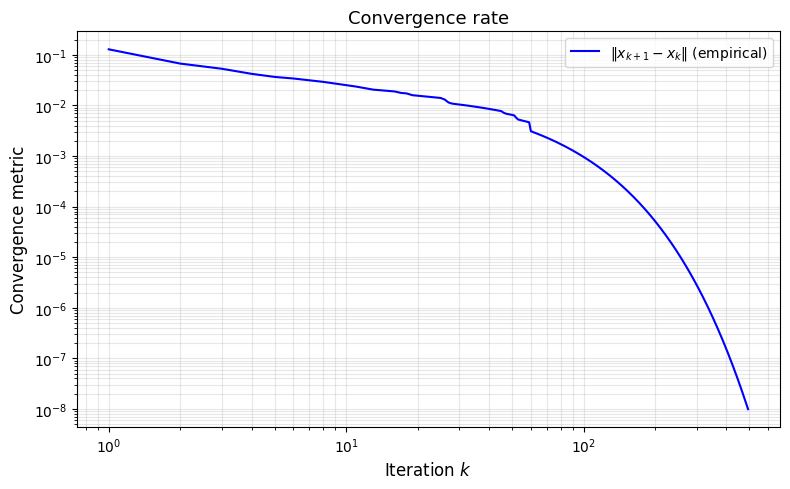

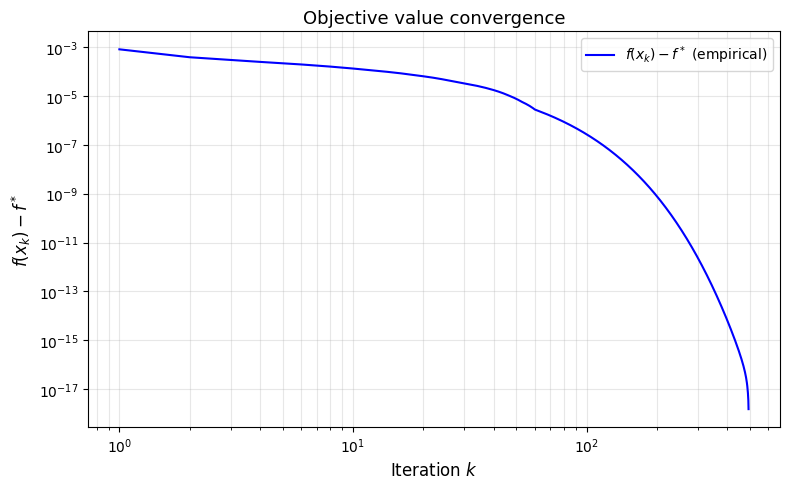

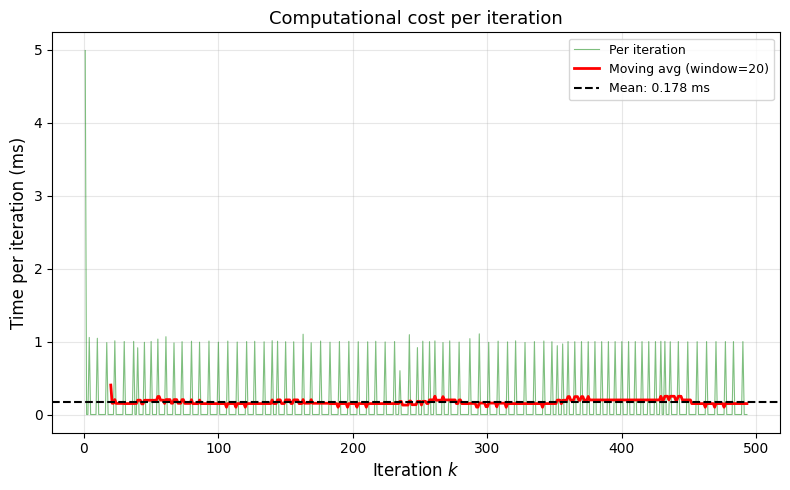

Total time: 0.0878 seconds
Total iterations: 493
Final objective value: -0.001049
Average time per iteration: 0.1782 ms
Std time per iteration: 0.4324 ms


In [5]:
# Plot convergence in iteration 


plot_convergence(result_ProjectedGradientMethod, theoretical_rate_exp=-0.5, rate_label=r'$O(k^{-1/2})$' , method_name="Projected_Gradient" , save_dir="../figures")

  tol=1.00e-02: 29 iterations
  tol=2.15e-03: 117 iterations
  tol=4.64e-04: 201 iterations
  tol=1.00e-04: 305 iterations
  tol=2.15e-05: 409 iterations
  tol=4.64e-06: 514 iterations
  tol=1.00e-06: 618 iterations
  tol=2.15e-07: 722 iterations
  tol=4.64e-06: 514 iterations
  tol=1.00e-06: 618 iterations
  tol=2.15e-07: 722 iterations
  tol=4.64e-08: 826 iterations
  tol=1.00e-08: 931 iterations
  tol=4.64e-08: 826 iterations
  tol=1.00e-08: 931 iterations


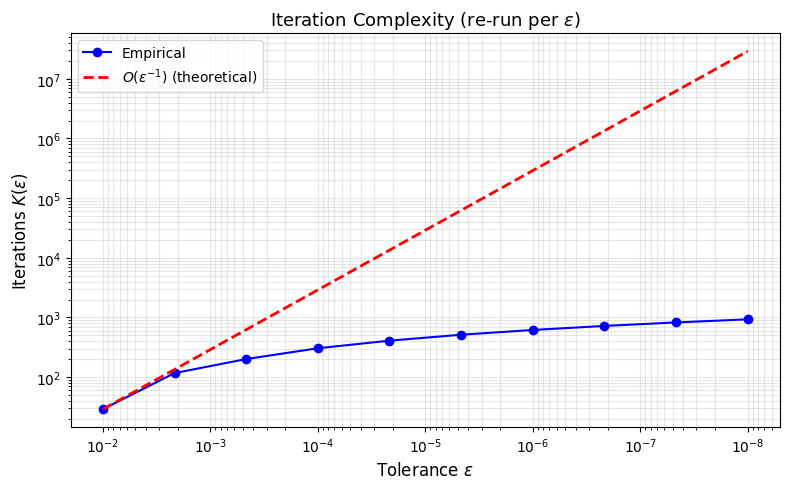

In [6]:
tolerances = np.logspace(-2, -8, 10)  # de 1e-2 à 1e-6

# Mesurer la complexité
result_complexity = measure_iteration_complexity(
    method_class=ProjectedGradientMethod,
    method_params={'step_size': 1.0 / L},
    model=model,
    w0=w0,
    tolerances=tolerances,
    theoretical_exp=1,
    rate_label=r'$O(\epsilon^{-1})$',
    method_name='ProjectedGD',
    save_dir='../figures'
)

#### Analyse with different stepsize

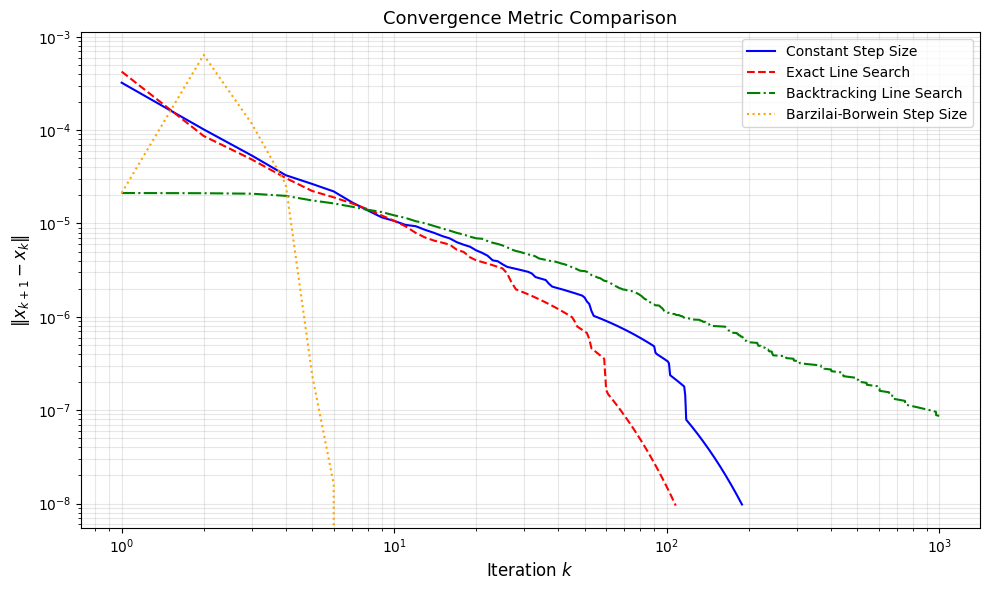

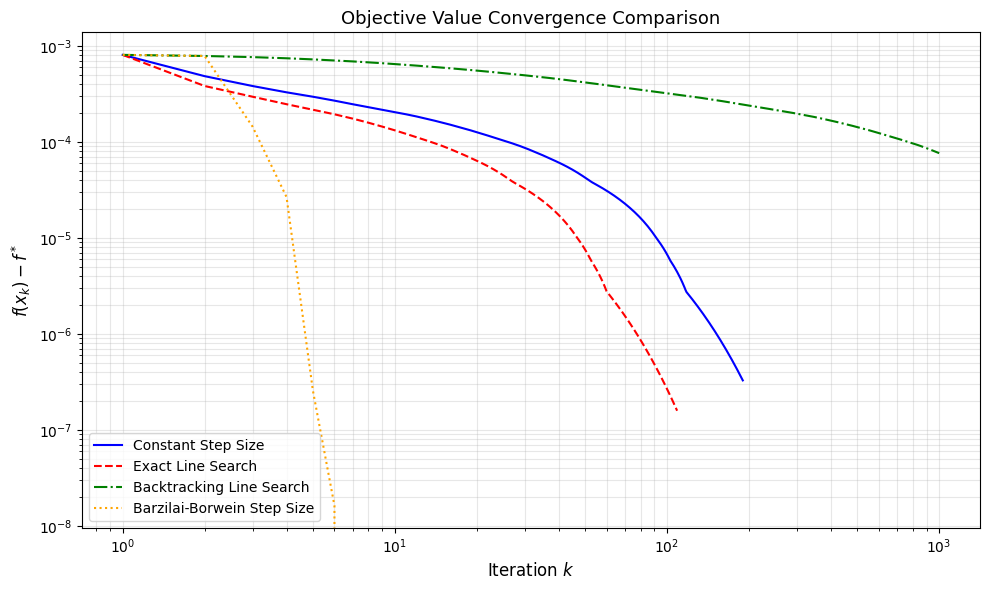

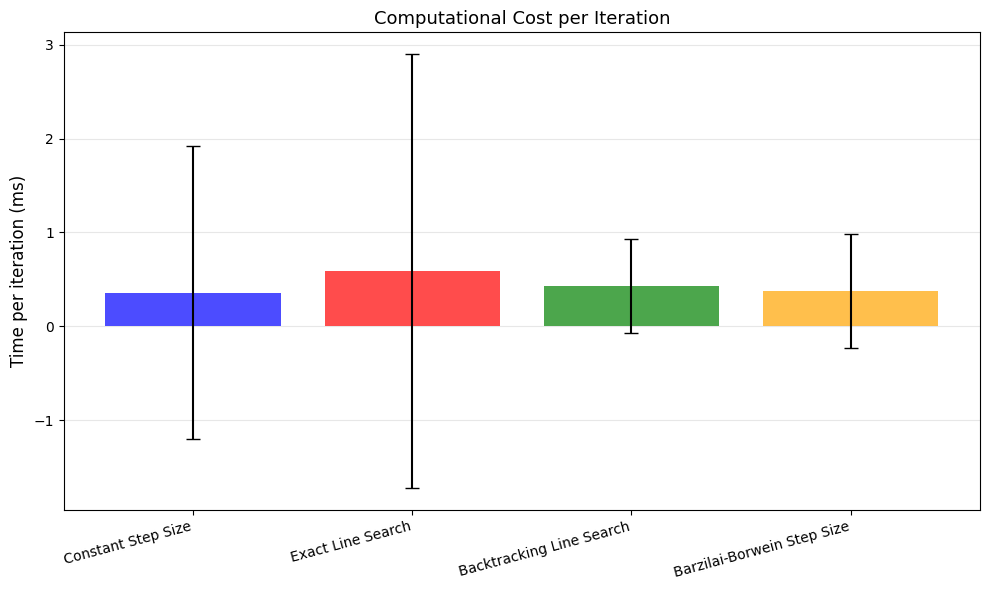

In [7]:
method1 = ProjectedGradientMethod({
    'step_size': ExactLineSearchQuadratic(),
    'max_iter': 1000,
    'tol':1e-8,
}, ValuePerformanceIndicator())
method1_result = method1.optimize(model, w0)
method2 = ProjectedGradientMethod({
    'step_size': 1.0 / L,
    'max_iter': 1000,
        'tol':1e-8,

}, ValuePerformanceIndicator())

method2_result = method2.optimize(model, w0)    

method3 =  ProjectedGradientMethod({
        'step_size': BacktrackingLineSearch(),
    'max_iter': 1000,
        'tol':1e-8,

}, ValuePerformanceIndicator())
method3_result = method3.optimize(model, w0)

method4 = ProjectedGradientMethod({
    'step_size': BarzilaiBorweinStepSize('BB1'),
    'max_iter': 1000,
        'tol':1e-8,

}, ValuePerformanceIndicator())
method4_result = method4.optimize(model, w0)

methods = {"Constant Step Size": method2_result,
           "Exact Line Search": method1_result,
           "Backtracking Line Search": method3_result,
           "Barzilai-Borwein Step Size": method4_result}
compare_methods(methods , method_name="Projected_Gradient_step_size" , save_dir="../figures")

### Projected gradient with momentum

In [8]:

L = model.lipschitz_constant()

# Create optimization method instance
method = ProjectedGradientDescentMomentum({
    'step_size': 1.0 / L,
    'max_iter': 1000,
    'tol': 1e-8,
    'momentum':0.9,
}, IteratePerformanceIndicator())

# Initial portfolio (equal weights)

# Optimize portfolio on training data
result_ProjectedGradientDescentMomentum = method.optimize(model, w0)

print("Keys disponibles:", result_ProjectedGradientDescentMomentum.keys())
print(f"Converged: {result_ProjectedGradientDescentMomentum['converged']}")
print(f"Iterations: {result_ProjectedGradientDescentMomentum['iterations']}")
#Plot valeur objectif en fonction des iterations





Keys disponibles: dict_keys(['sol', 'value', 'iterations', 'converged', 'metric', 'time', 'obj_value', 'step_sizes'])
Converged: True
Iterations: 811


#### Analyse convergence Projected gradient with momentum

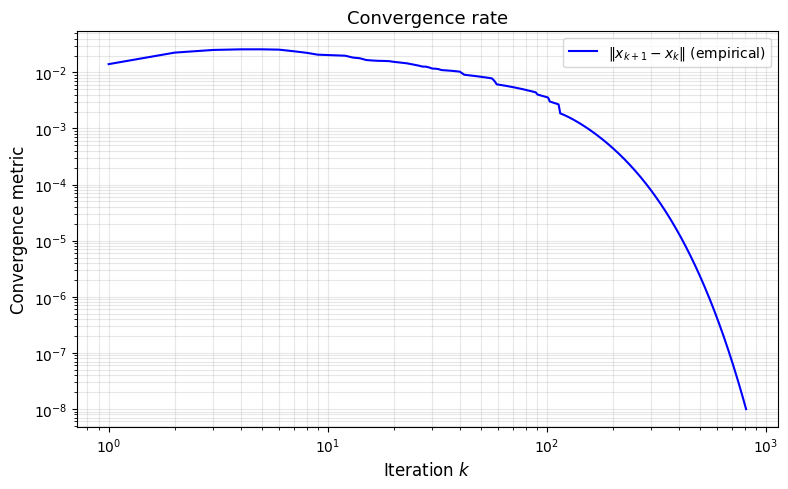

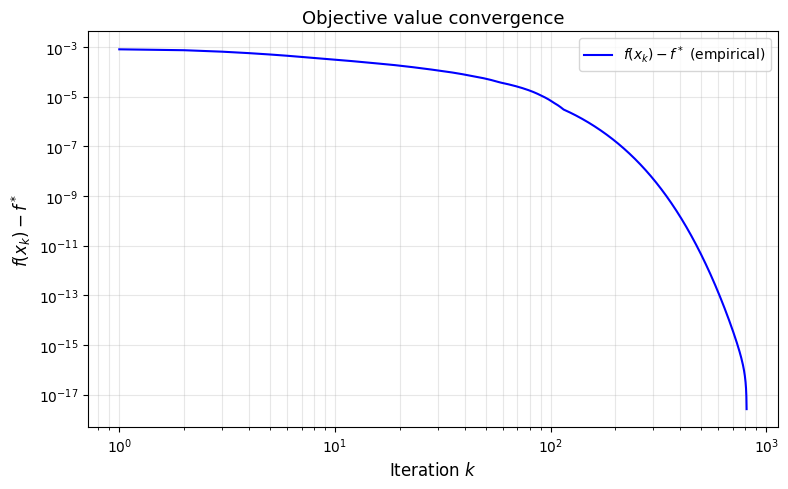

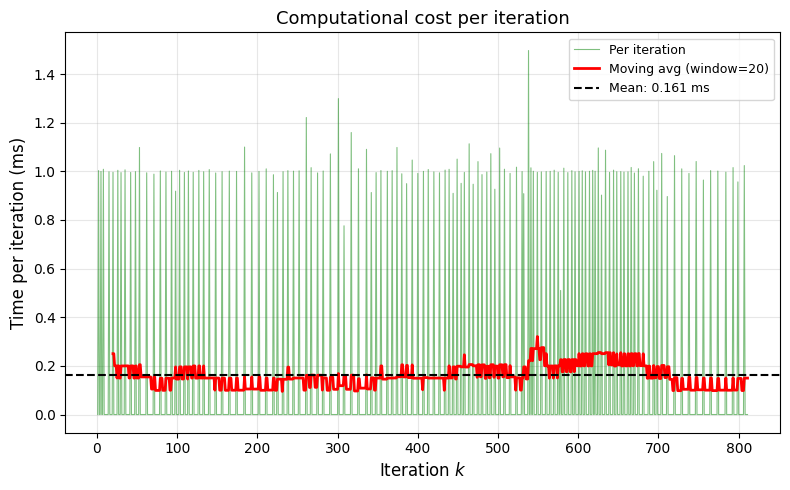

Total time: 0.1308 seconds
Total iterations: 811
Final objective value: -0.001049
Average time per iteration: 0.1612 ms
Std time per iteration: 0.3705 ms


In [9]:
plot_convergence(result_ProjectedGradientDescentMomentum , method_name="Projected_Gradient_momentum" , save_dir="../figures")

  tol=1.00e-02: 41 iterations
  tol=2.15e-03: 115 iterations
  tol=4.64e-04: 198 iterations
  tol=1.00e-04: 286 iterations
  tol=2.15e-05: 373 iterations
  tol=4.64e-06: 461 iterations
  tol=1.00e-06: 548 iterations
  tol=2.15e-07: 636 iterations
  tol=4.64e-06: 461 iterations
  tol=1.00e-06: 548 iterations
  tol=2.15e-07: 636 iterations
  tol=4.64e-08: 723 iterations
  tol=1.00e-08: 811 iterations
  tol=4.64e-08: 723 iterations
  tol=1.00e-08: 811 iterations


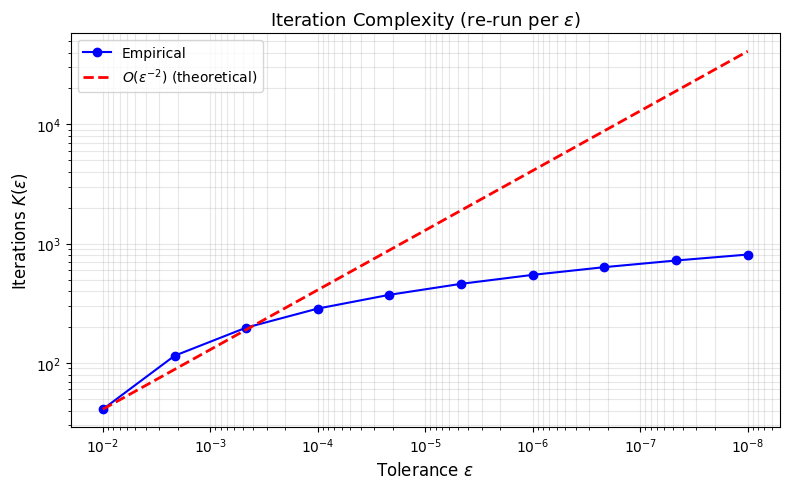

In [10]:
tolerances = np.logspace(-2, -8, 10)  # de 1e-2 à 1e-6

result_complexity = measure_iteration_complexity(
    method_class=ProjectedGradientDescentMomentum,
    method_params={
    'step_size': 1.0 / L,
    'max_iter': 1000,
    'tol': 1e-8,
    'momentum':0.9,
},
    model=model,
    w0=w0,
    tolerances=tolerances,
    theoretical_exp=0.5,
    rate_label=r'$O(\epsilon^{-2})$',
    method_name='ProjectedGD_momentum',
    save_dir='../figures'
)

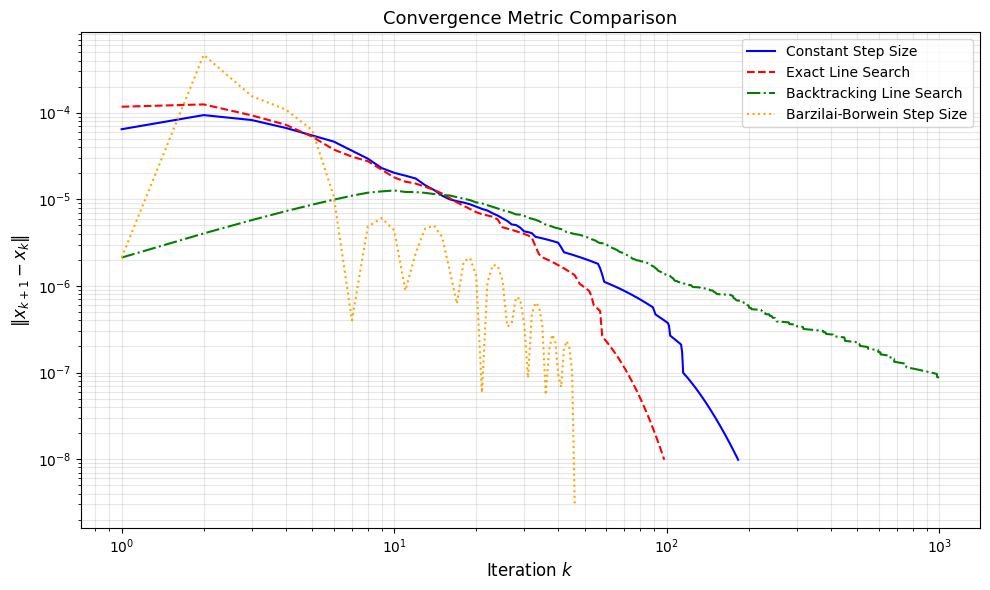

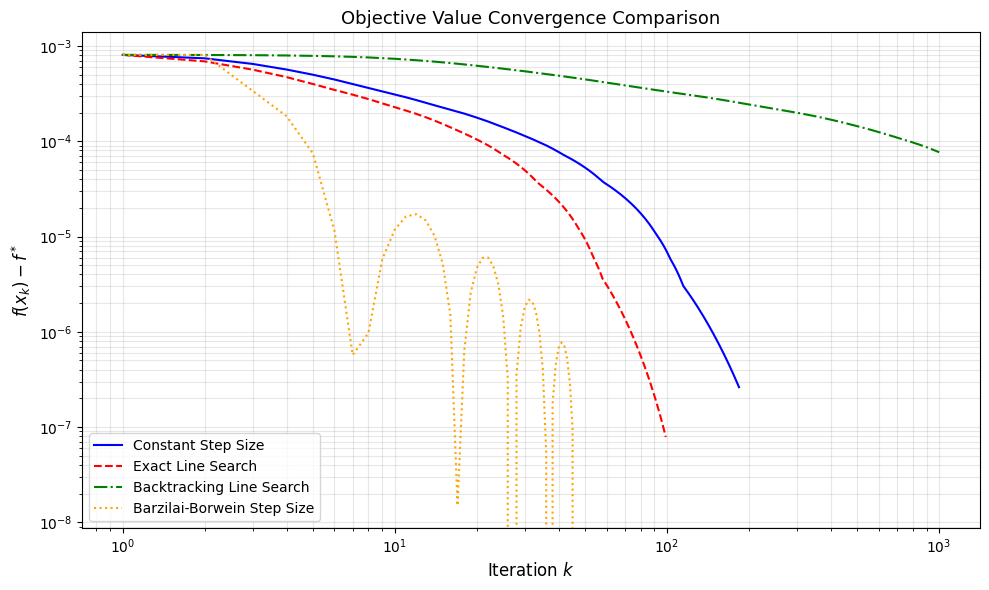

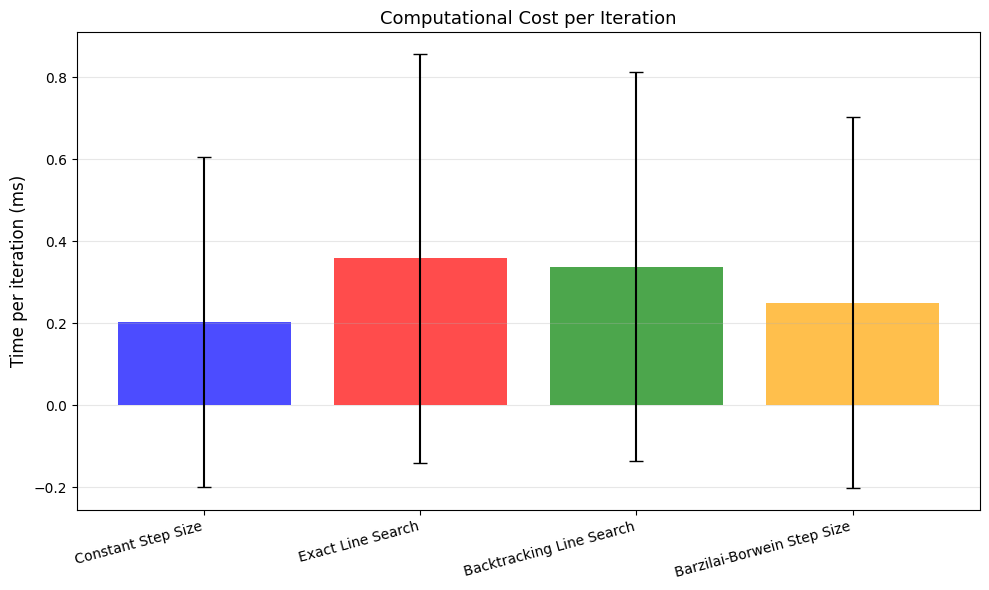

In [11]:
method1 = ProjectedGradientDescentMomentum({
    'step_size': ExactLineSearchQuadratic(),
    'max_iter': 1000,
        'tol': 1e-8,

}, ValuePerformanceIndicator())
method1_result = method1.optimize(model, w0)
method2 = ProjectedGradientDescentMomentum({
    'step_size': 1.0 / L,
    'max_iter': 1000,
        'tol': 1e-8,

}, ValuePerformanceIndicator())

method2_result = method2.optimize(model, w0)    

method3 =  ProjectedGradientDescentMomentum({
        'step_size': BacktrackingLineSearch(),
    'max_iter': 1000,
        'tol': 1e-8,

}, ValuePerformanceIndicator())
method3_result = method3.optimize(model, w0)

method4 = ProjectedGradientDescentMomentum({
    'step_size': BarzilaiBorweinStepSize('BB1'),
    'max_iter': 1000,
    'tol': 1e-8,
}, ValuePerformanceIndicator())
method4_result = method4.optimize(model, w0)

methods = {"Constant Step Size": method2_result,
           "Exact Line Search": method1_result,
           "Backtracking Line Search": method3_result,
           "Barzilai-Borwein Step Size": method4_result}
compare_methods(methods , method_name="Projected_Gradient_momentum_step_size" , save_dir="../figures")

#### Projected Randomized Coordinate Descent

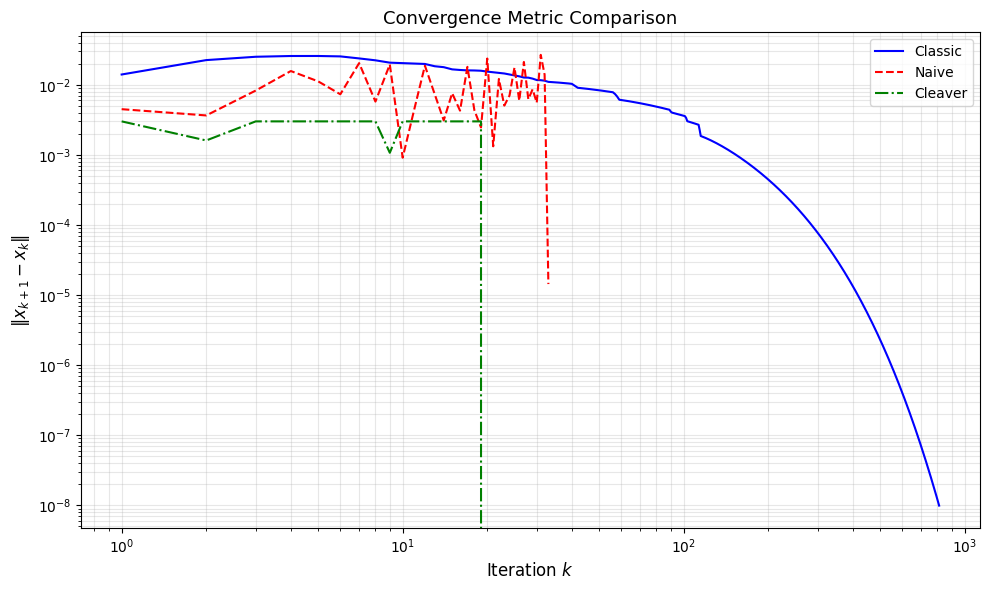

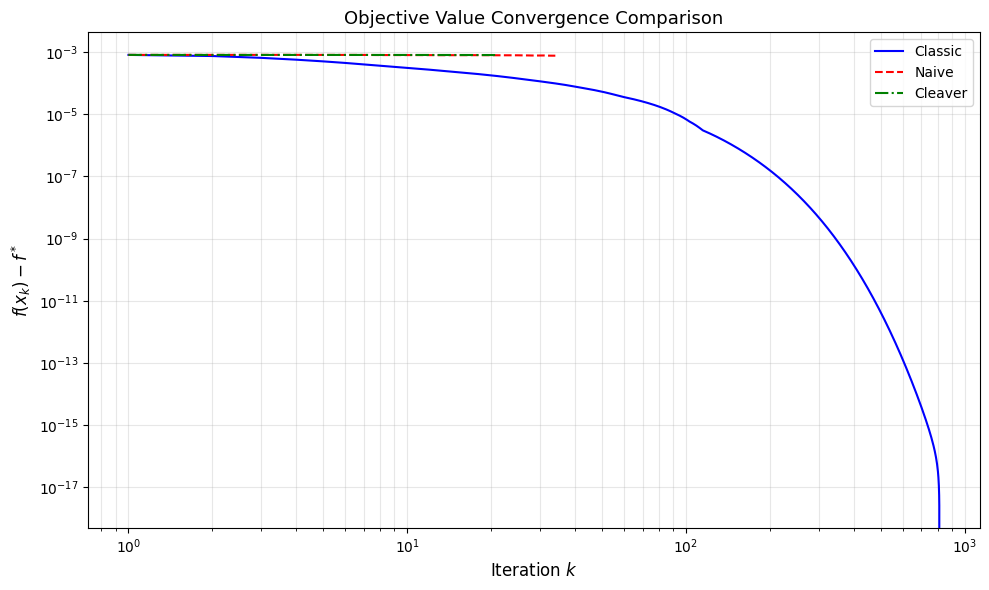

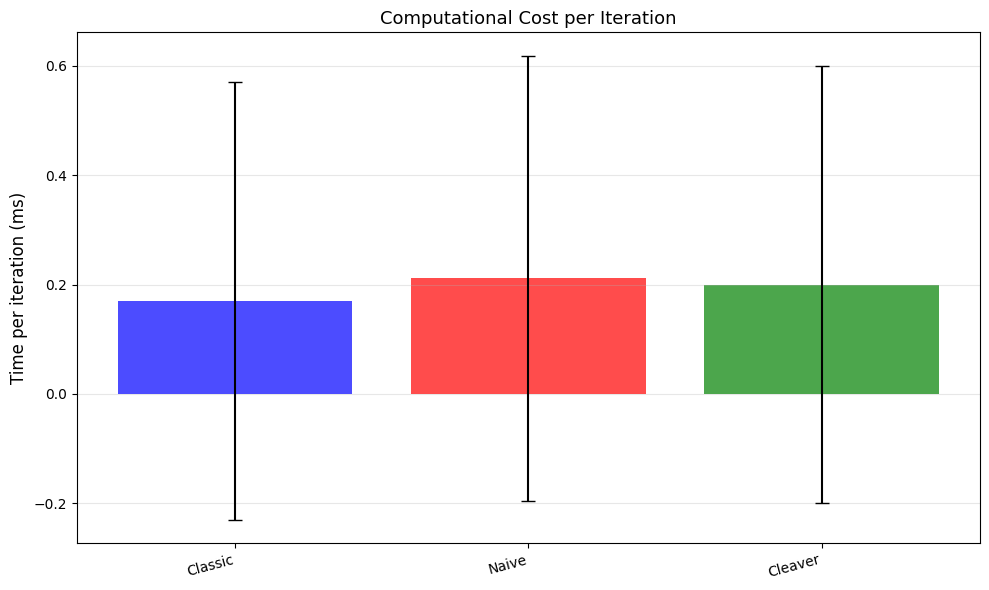

In [12]:
L = model.lipschitz_constant()

# Create optimization method instance
method1 = ProjectedRandomizedCoordinateDescent({
    'step_size': 1.0 / L,
    'max_iter': 1000,
    'tol': 1e-8,
    'iter_met': "Naive"
}, ValuePerformanceIndicator())

metod2 = ProjectedRandomizedCoordinateDescent({
    'step_size': 1.0 / L,
    'max_iter': 1000,
    'tol': 1e-8,
    'iter_met': "Naive2"
}, ValuePerformanceIndicator())

method3 = ProjectedRandomizedCoordinateDescent({
    'step_size': 1.0 / L,
    'max_iter': 1000,
    'tol': 1e-8,
    'iter_met': ""
}, ValuePerformanceIndicator())

# Optimize portfolio on training data
result1_ProjectedRandomizedCoordinateDescent = method.optimize(model, w0)
result2_ProjectedRandomizedCoordinateDescent = metod2.optimize(model, w0)
result3_ProjectedRandomizedCoordinateDescent = method3.optimize(model, w0)
methods = {"Classic": result1_ProjectedRandomizedCoordinateDescent,
           "Naive": result2_ProjectedRandomizedCoordinateDescent,
           "Cleaver": result3_ProjectedRandomizedCoordinateDescent}
compare_methods(methods , method_name="Projected_Randomized_Coordinate_Descent_iteration_method" , save_dir="../figures")


#### Analyse convergence GradientDescentRandomized

In [13]:
plot_convergence(result_ProjectedRandomizedCoordinateDescent, method_name="Projected_Randomized_Coordinate_Descent" , save_dir="../figures")

NameError: name 'result_ProjectedRandomizedCoordinateDescent' is not defined

#### Further analysis on Randomized coordinate descent

#### Comparaison of the methods 

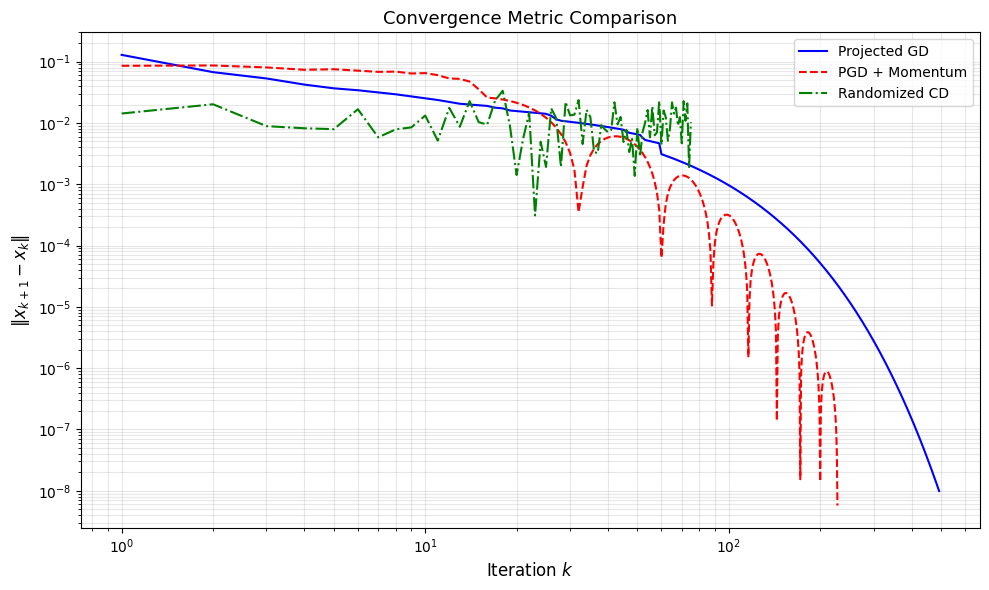

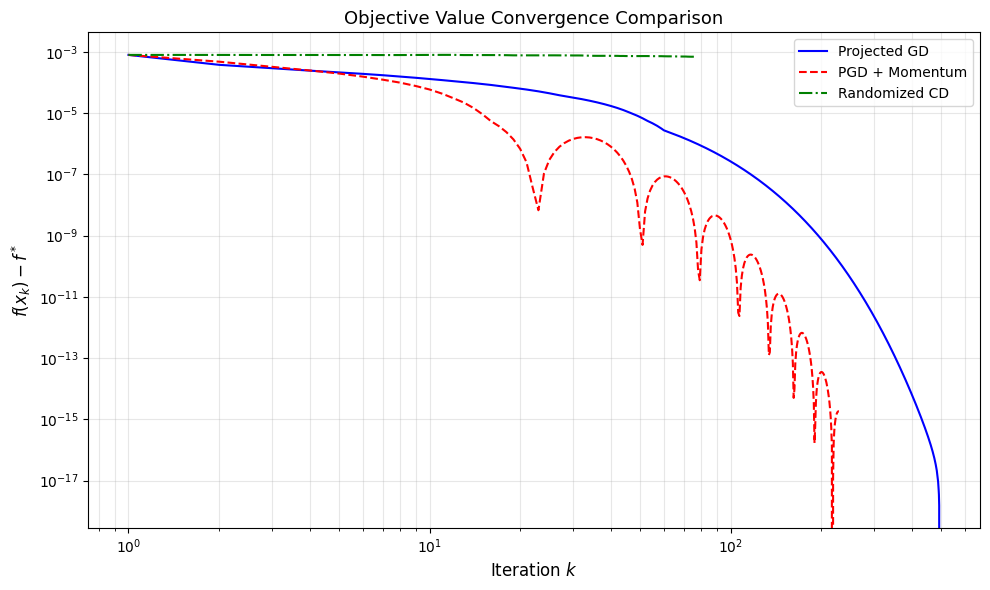

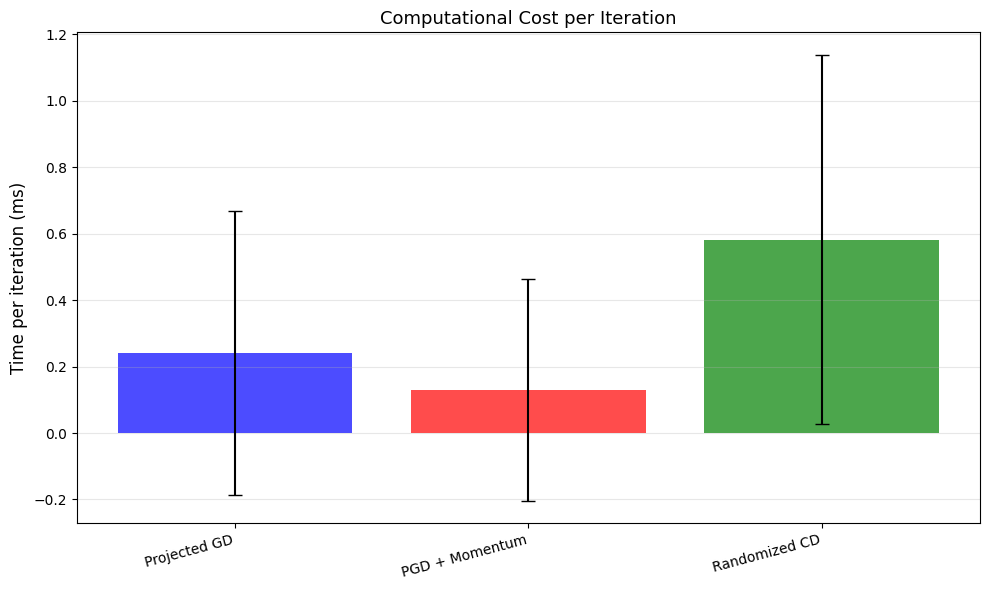

In [ ]:
compare_methods({
    'Projected GD': result_ProjectedGradientMethod,
    'PGD + Momentum': result_ProjectedGradientDescentMomentum,
    'Randomized CD': result2_ProjectedRandomizedCoordinateDescent,
})

#### Further analysis of the RandomizedCoordinateDescent 

### Non smooth model

In [ ]:
# Create Non-Smooth Model instance
# w_prev: previous portfolio (for transaction costs)
# c: transaction cost coefficient (penalizes ||w - w_prev||_1)

n = data['mu'].shape[0]

# Option 1: w_prev = uniform portfolio (no transaction cost at start if w0 = uniform)
# w_prev = get_initial_portfolio(n)

# Option 2: w_prev = random portfolio (simulates rebalancing from existing position)
np.random.seed(42)  # For reproducibility
w_prev = get_initial_portfolio(n, method="random")

print(f"Previous portfolio (w_prev): first 5 weights = {w_prev[:5]}")
print(f"Sum of w_prev: {np.sum(w_prev):.6f}")

model_non_smooth = NonSmoothMarkowitzModel({
    "mu": data['mu'],
    "sigma": data['sigma'],
    "lam": 0.5,
    "w_prev": w_prev,  # Previous portfolio for transaction costs
    "c": 0.01,         # Transaction cost coefficient
})

# Initial point for optimization (uniform)
w0 = get_initial_portfolio(n)
print(f"\nInitial point (w0): first 5 weights = {w0[:5]}")
print(f"||w0 - w_prev||_1 = {np.linalg.norm(w0 - w_prev, 1):.4f}")

Previous portfolio (w_prev): first 5 weights = [0.00101809 0.00653053 0.00285671 0.00198065 0.00036801]
Sum of w_prev: 1.000000

Initial point (w0): first 5 weights = [0.00212766 0.00212766 0.00212766 0.00212766 0.00212766]
||w0 - w_prev||_1 = 0.7387


#### Projected Subgradient Method

Keys disponibles: dict_keys(['sol', 'value', 'iterations', 'converged', 'metric', 'time', 'obj_value'])
Converged: False
Iterations: 100000
Final objective value: -0.000222


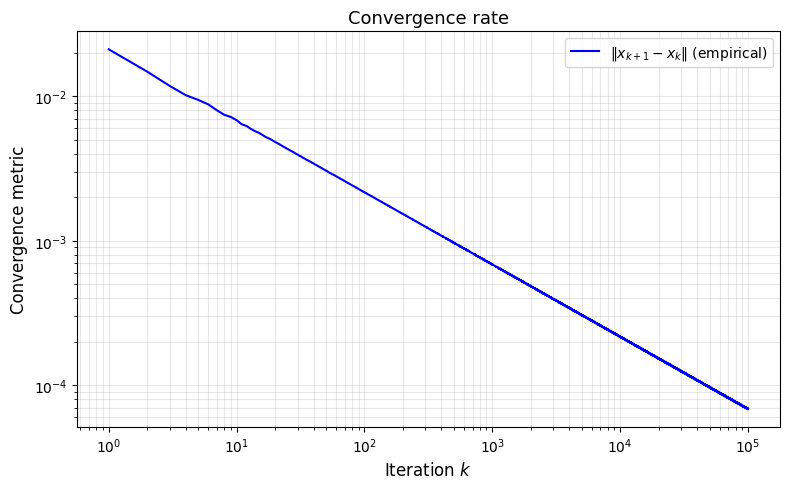

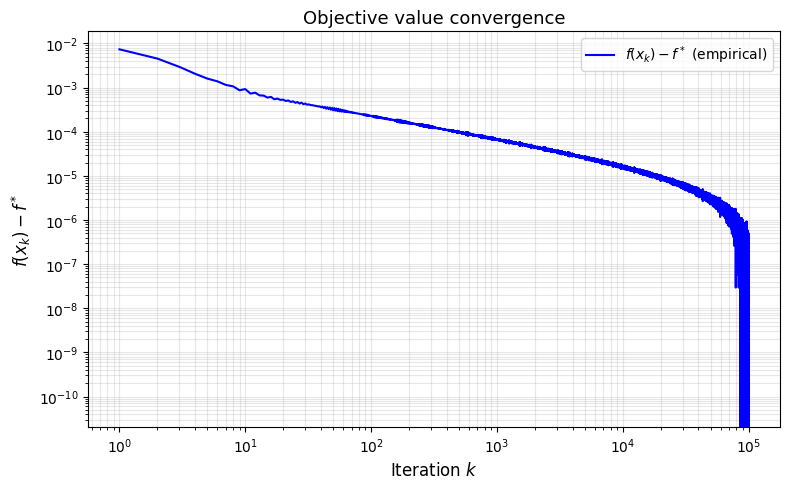

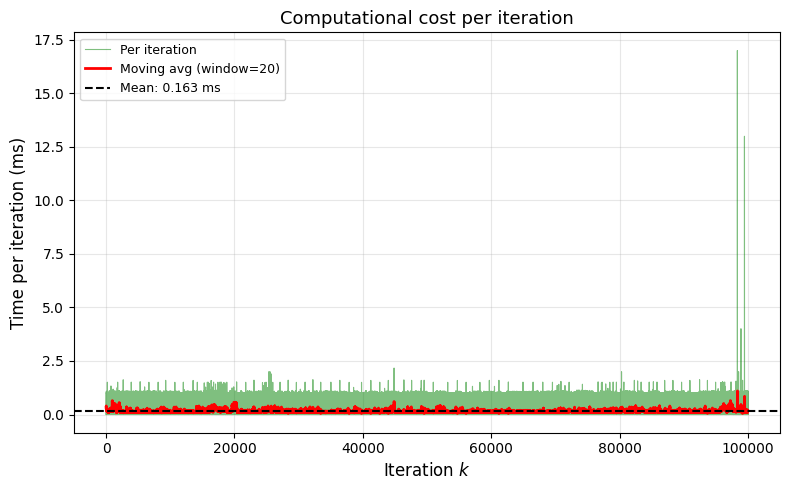

Total time: 16.3074 seconds
Total iterations: 100000
Final objective value: -0.000221
Average time per iteration: 0.1631 ms
Std time per iteration: 0.3773 ms


In [ ]:
# For subgradient methods, we need DIMINISHING step size to converge!
# Constant step size only converges to a neighborhood of the optimum

method = ProjectedSubgradientMethod({
    'step_size': 0.1,              # Initial step size α_0
    'step_size_rule': 'diminishing',  # α_k = α_0 / sqrt(k)
    'max_iter': 100000,
    'tol': 1e-6,
}, IteratePerformanceIndicator())

# Initial portfolio (equal weights)
w0 = get_initial_portfolio(data['mu'].shape[0])

# Optimize portfolio on training data
result_ProjectedSubgradientMethod = method.optimize(model_non_smooth, w0)

print("Keys disponibles:", result_ProjectedSubgradientMethod.keys())
print(f"Converged: {result_ProjectedSubgradientMethod['converged']}")
print(f"Iterations: {result_ProjectedSubgradientMethod['iterations']}")
print(f"Final objective value: {result_ProjectedSubgradientMethod['value']:.6f}")

# Plot convergence
plot_convergence(result_ProjectedSubgradientMethod)

#### Proximal Gradient Method

Keys disponibles: dict_keys(['sol', 'value', 'iterations', 'converged', 'metric', 'time', 'obj_value'])
Converged: True
Iterations: 9
Final objective value: -0.000228


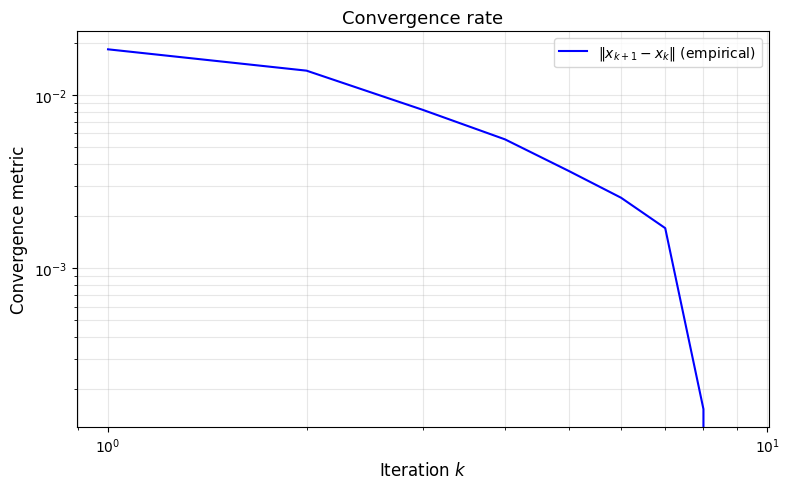

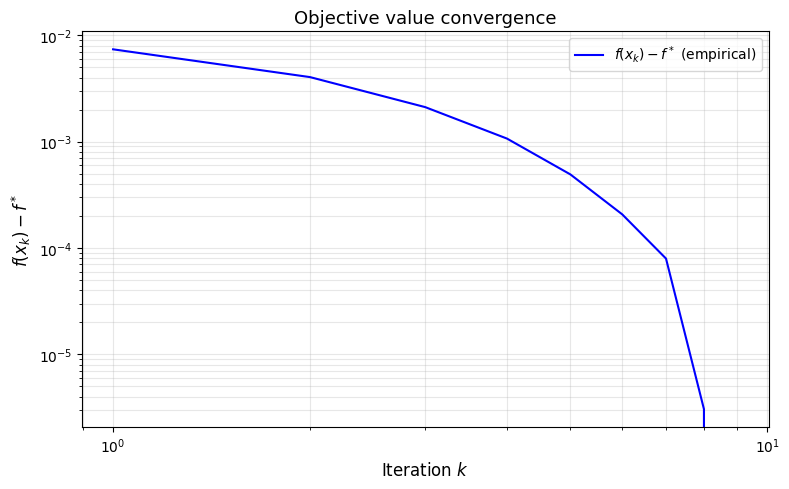

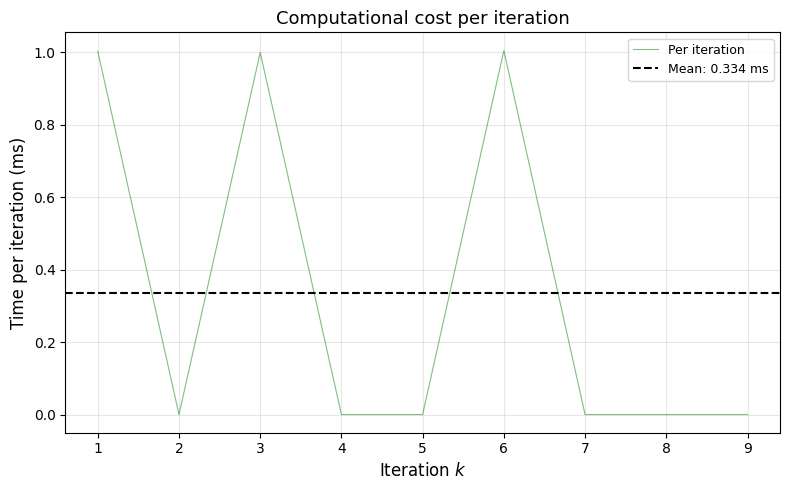

Total time: 0.0030 seconds
Total iterations: 9
Final objective value: -0.000228
Average time per iteration: 0.3341 ms
Std time per iteration: 0.4725 ms


In [ ]:
# For subgradient methods, we need DIMINISHING step size to converge!
# Constant step size only converges to a neighborhood of the optimum

method = ProximalGradientMethod({
    'step_size': 0.1,              # Initial step size α_0
    'max_iter': 100000,
    'tol': 1e-6,
}, IteratePerformanceIndicator())

# Initial portfolio (equal weights)
w0 = get_initial_portfolio(data['mu'].shape[0])

# Optimize portfolio on training data
result_ProjectedSubgradientMethod = method.optimize(model_non_smooth, w0)

print("Keys disponibles:", result_ProjectedSubgradientMethod.keys())
print(f"Converged: {result_ProjectedSubgradientMethod['converged']}")
print(f"Iterations: {result_ProjectedSubgradientMethod['iterations']}")
print(f"Final objective value: {result_ProjectedSubgradientMethod['value']:.6f}")

# Plot convergence
plot_convergence(result_ProjectedSubgradientMethod)

#### IteriorPointMethod

In [ ]:
# Interior Point Method works best for SMOOTH problems
# For non-smooth problems (L1 penalty), use Subgradient or Proximal methods

# Apply to the SMOOTH model
method = InteriorPointMethod({
    'mu': 1.0,           # Initial barrier parameter
    'mu_decay': 0.5,     # Decay factor
    'max_iter': 1000,
    'max_inner_iter': 20,
    'tol': 1e-8,
    'inner_tol': 1e-10,
}, IteratePerformanceIndicator())

w0 = get_initial_portfolio(data['mu'].shape[0])

# Use the SMOOTH model (not non-smooth!)
result_InteriorPointMethod = method.optimize(model, w0)  # 'model' is smooth

print("Keys disponibles:", result_InteriorPointMethod.keys())
print(f"Converged: {result_InteriorPointMethod['converged']}")
print(f"Iterations: {result_InteriorPointMethod['iterations']}")
print(f"Final objective value: {result_InteriorPointMethod['value']:.6f}")

# Compare with Projected GD result
print(f"\nComparison with Projected GD:")
print(f"  Interior Point: {result_InteriorPointMethod['value']:.6f}")
print(f"  Projected GD:   {result_ProjectedGradientMethod['value']:.6f}")

# Plot convergence
plot_convergence(result_InteriorPointMethod)

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "C:\Users\guera\AppData\Roaming\Python\Python311\site-packages\IPython\core\interactiveshell.py", line 3548, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\guera\AppData\Local\Temp\ipykernel_10056\904492776.py", line 17, in <module>
    result_InteriorPointMethod = method.optimize(model, w0)  # 'model' is smooth
                                 ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\guera\Bureau\Univeriste\Q7\LINMA2471 - Optimization models and methods II\Project\python\methods\methods.py", line 782, in optimize
    rhs[:n] = -barrier_grad
                    ^^^^^^^^
  File "c:\Users\guera\Bureau\Univeriste\Q7\LINMA2471 - Optimization models and methods II\Project\python\methods\methods.py", line 830, in _newton_step
  File "c:\Users\guera\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_twodim_base_impl.py", line 305, in diag
    res = zeros((n, n), v.dtype)
          ^^^^^^^^^^^^^^